# 📊 Patient Pathway Analysis — Statistical Analysis

**Objective:** Test hypotheses on patient healthcare utilisation using inferential statistics, and model the relationship between age and visit intensity.

**Data source:** `../database/patient_journey.db`  
**Stack:** Python · pandas · scipy · statsmodels · matplotlib  

---
**Analysis sections:**
1. Descriptive statistics (distribution, central tendency), (Recall of cohort KPIs: Age, Gender, Visits, and Multimorbidity)
2. Inferential statistics
   - 2.1 Chi-square test — gender vs chronic status (5+ conditions)
   - 2.2 Mann-Whitney test — visit intensity by obesity status
   - 2.3 Welch t-test — age groups vs visits
3. Linear regression — age as predictor of healthcare utilisation
4. Conclusions & limitations

# 1. Imports & Database Connection

In [19]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
import statsmodels.api as sm
import os

conn = sqlite3.connect("../database/patient_journey.db")
print("✅ Connected to patient_journey.db")

✅ Connected to patient_journey.db


# 2. Descriptive Statistics

Before running hypothesis tests, we assess the distribution of key variables. Comparing mean vs median helps detect skewness and informs the choice of parametric vs non-parametric tests.

## 2.1 Age Distribution & Normality Assessment

Mean age  : 44.5 years
Median age: 44.9 years
Std dev   : 25.1 years

Mean vs Median difference: 0.4 years
→ Parametric tests may be preferable.


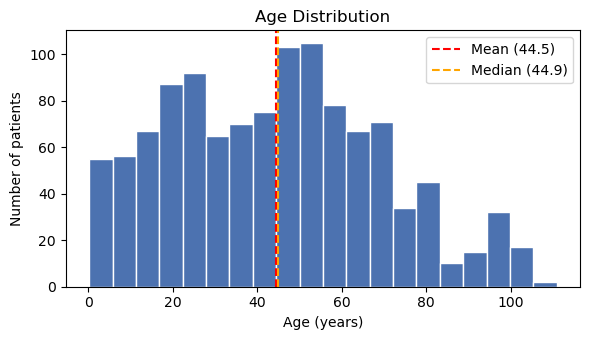

In [14]:
ages = pd.read_sql("""
    SELECT (julianday('now') - julianday(birth_date)) / 365.25 AS age
    FROM patients;
""", conn)

# Age distribution
mean_age   = ages["age"].mean()
median_age = ages["age"].median()
std_age    = ages["age"].std()

print(f"Mean age  : {mean_age:.1f} years")
print(f"Median age: {median_age:.1f} years")
print(f"Std dev   : {std_age:.1f} years")
print(f"\nMean vs Median difference: {abs(mean_age - median_age):.1f} years")
print("→ Parametric tests may be preferable.")

fig, ax = plt.subplots(figsize=(6, 3.5))

# Age histogram
ax.hist(ages["age"], bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(mean_age, color="red", linestyle="--", label=f"Mean ({mean_age:.1f})")
ax.axvline(median_age, color="orange", linestyle="--", label=f"Median ({median_age:.1f})")
ax.set_title("Age Distribution")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of patients")
ax.legend()
plt.tight_layout()
plt.show()

## 2.2 Visit Distribution & Normality Assessment

Mean visits  : 58.6 visits
Median visits: 36.0 visits
Std dev      : 87.1 visits

Mean vs Median difference: 22.6 visits
→ Non-parametric tests may be preferable.


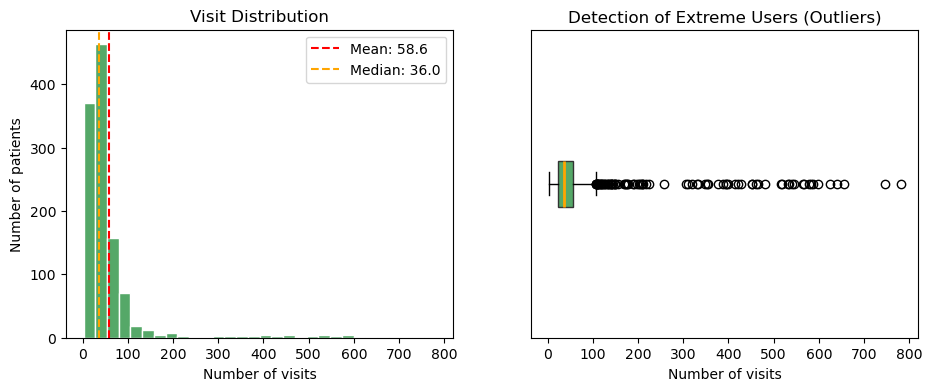

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

visits = pd.read_sql(
    """
    SELECT patient_id, COUNT(*) AS nb_visits
    FROM encounters
    GROUP BY patient_id;
""",
    conn,
)

mean_visits = visits["nb_visits"].mean()
median_visits = visits["nb_visits"].median()
std_visits = visits["nb_visits"].std()

print(f"Mean visits  : {mean_visits:.1f} visits")
print(f"Median visits: {median_visits:.1f} visits")
print(f"Std dev      : {std_visits:.1f} visits")
print(
    f"\nMean vs Median difference: {abs(mean_visits - median_visits):.1f} visits"
)
print("→ Non-parametric tests may be preferable.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))


axes[0].hist(visits["nb_visits"], bins=30, color="#55A868", edgecolor="white")
axes[0].axvline(
    mean_visits,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_visits:.1f}",
)
axes[0].axvline(
    median_visits,
    color="orange",
    linestyle="--",
    label=f"Median: {median_visits:.1f}",
)
axes[0].set_title("Visit Distribution")
axes[0].set_xlabel("Number of visits")
axes[0].set_ylabel("Number of patients")
axes[0].legend()

axes[1].boxplot(visits["nb_visits"], vert=False, patch_artist=True, 
                boxprops=dict(facecolor="#55A868", color="#333333"),
                medianprops=dict(color="orange", linewidth=2))
axes[1].set_title("Detection of Extreme Users (Outliers)")
axes[1].set_xlabel("Number of visits")
axes[1].set_yticks([])

output_dir = "../plots"
os.makedirs(output_dir, exist_ok=True)
plt.savefig("../plots/visits_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


## 3. Inferential Statistics

### 3.1 Chi-square Test — Gender vs Chronic Status

**Question:** Is there a statistically significant association between patient gender and the presence of multiple chronic conditions (defined as having 5 or more diagnosed conditions in the database)?

**Context & Clinical Relevance:** Multimorbidity (the coexistence of multiple conditions) is a major challenge for modern healthcare systems. Tracking patients with a high accumulation of diagnoses >= 5 allows epidemiologists to identify the most vulnerable clinical profiles. Analyzing this status against gender helps determine if risk mitigation and integrated care pathways should be tailored differently for male and female populations, or if the burden of severe chronic disease is homogeneously distributed.

**Test:** We apply the Pearson Chi-square test of independence because we are evaluating the relationship between two distinct categorical variables: Gender (Male vs. Female) and Multi-Chronic Status (Multi-Chronic >= 5 conditions vs. Standard >= 5 conditions).

Contingency table:


status,complex_chronic,standard
gender,,
F,559,4
M,576,7



Chi-square statistic : 0.300
Degrees of freedom   : 1
p-value              : 0.5838
→ No significant association found (p ≥ 0.05).


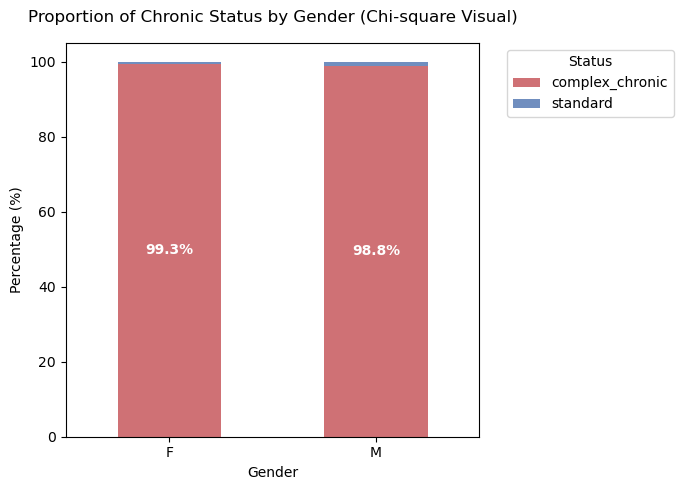

In [28]:
table = pd.read_sql("""
    SELECT
        p.gender,
        CASE WHEN COUNT(c.condition_name) >= 5 THEN 'complex_chronic' ELSE 'standard' END AS status
    FROM patients p
    LEFT JOIN conditions c ON p.patient_id = c.patient_id
    GROUP BY p.patient_id;
""", conn)

contingency = pd.crosstab(table["gender"], table["status"])
print("Contingency table:")
display(contingency)

chi2, p_chi2, dof, expected = chi2_contingency(contingency)

print(f"\nChi-square statistic : {chi2:.3f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {p_chi2:.4f}")

if p_chi2 < 0.05:
    print("→ Significant association between gender and chronic status (p < 0.05).")
else:
    print("→ No significant association found (p ≥ 0.05).")

contingency_perc = contingency.div(contingency.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(7, 5))
contingency_perc.plot(
    kind="bar", 
    stacked=True, 
    color=["#C44E52", "#4C72B0"], # Rouge pour complex_chronic, Bleu pour standard
    alpha=0.8,
    ax=ax
)

ax.set_title("Proportion of Chronic Status by Gender (Chi-square Visual)", fontsize=12, pad=15)
ax.set_xlabel("Gender")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0) # Pour garder 'F' et 'M' bien droits
ax.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left') # Légende décalée pour ne pas gêner

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # On n'affiche le texte que si la barre est assez grande
        ax.text(x + width/2, 
                y + height/2, 
                f"{height:.1f}%", 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold')

plt.tight_layout()
plt.savefig("../plots/assoc_gender_complex.png", dpi=300, bbox_inches="tight")
plt.show()


## 3.2 Mann-Whitney Test — Visit Intensity by obesity Status

**Question:** Do patients diagnosed with obesity differ significantly in their total number of healthcare visits compared to patients without this diagnosis?

**Context & Clinical Relevance:** Obesity is a complex, chronic condition frequently associated with a higher risk of comorbidities (such as cardiovascular diseases or metabolic disorders). Tracking the total number of encounters allows us to measure the overall healthcare utilization and the medical burden associated with this condition in our patient population.

**Test:** We apply the Mann-Whitney U test (a non-parametric method). This choice is mandatory because the distribution of total visits per patient is heavily right-skewed, exhibiting a high concentration of patients with low-to-moderate utilization and a long tail of extreme high-utilizers (outliers). Since the assumptions of normality required for a standard t-test are strictly violated here, the Mann-Whitney U test provides a robust and mathematically valid comparison of the two groups.

=== MANN-WHITNEY U TEST: OBESITY VS VISITS ===
U-statistic = 222554.00
p-value     = 8.5511e-26
→ Statistically Significant! Patients with obesity (median: 45 visits) have a significantly different care intensity than other patients (median: 29 visits).


C:\Users\Juliette Vanessa\AppData\Local\Temp\ipykernel_30656\1950707781.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


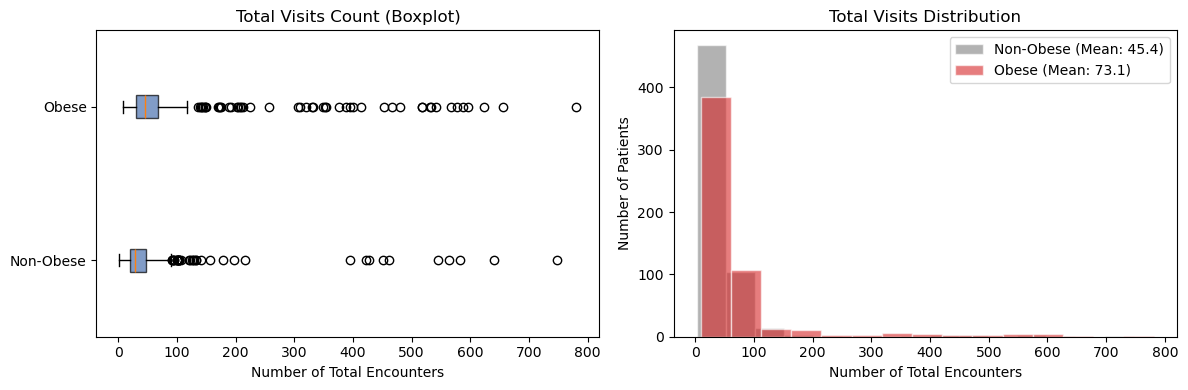

In [32]:
# Obesity group total visits
obese_visits = pd.read_sql("""
   SELECT COUNT(e.encounter_id) AS nb
    FROM (
        SELECT DISTINCT patient_id 
        FROM conditions 
        WHERE condition_name = 'Body mass index 30+ - obesity (finding)'
    ) o
    LEFT JOIN encounters e ON o.patient_id = e.patient_id
    GROUP BY o.patient_id;
""", conn)["nb"]

# Non-Obesity group
non_obese_visits = pd.read_sql("""
    SELECT COUNT(e.encounter_id) AS nb
    FROM (
        SELECT patient_id FROM patients
        EXCEPT
        SELECT DISTINCT patient_id 
        FROM conditions 
        WHERE condition_name = 'Body mass index 30+ - obesity (finding)'
    ) no
    LEFT JOIN encounters e ON no.patient_id = e.patient_id
    GROUP BY no.patient_id;
""", conn)["nb"]

u_stat, p_val = stats.mannwhitneyu(
    obese_visits, non_obese_visits, alternative="two-sided"
)

print("=== MANN-WHITNEY U TEST: OBESITY VS VISITS ===")
print(f"U-statistic = {u_stat:.2f}")
print(f"p-value     = {p_val:.4e}")

if p_val < 0.05:
    print(
       f"→ Statistically Significant! Patients with obesity (median: {obese_visits.median():.0f} visits) "
        f"have a significantly different care intensity than other patients (median: {non_obese_visits.median():.0f} visits)."
    )
else:
    print("→ Not Statistically Significant. No meaningful difference detected between the two groups.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : Boxplot
axes[0].boxplot(
    [non_obese_visits, obese_visits],
    labels=["Non-Obese", "Obese"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.7),
)
axes[0].set_title("Total Visits Count (Boxplot)")
axes[0].set_xlabel("Number of Total Encounters")

# Graphique 2 : Histogrammes superposés
axes[1].hist(
    non_obese_visits, 
    bins=15, 
    alpha=0.6, 
    color="#7F7F7F", 
    edgecolor="white", 
    label=f"Non-Obese (Mean: {non_obese_visits.mean():.1f})"
)
axes[1].hist(
    obese_visits, 
    bins=15, 
    alpha=0.6, 
    color="#D62728", 
    edgecolor="white", 
    label=f"Obese (Mean: {obese_visits.mean():.1f})"
)
axes[1].set_title("Total Visits Distribution")
axes[1].set_xlabel("Number of Total Encounters")
axes[1].set_ylabel("Number of Patients")
axes[1].legend()
plt.savefig("../plots/assoc_vivits_complex.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 3.3 Welch T-test — Younger vs Older Patients

**Question:** Do younger and older patients (split at median age) differ in healthcare utilisation?  

**Context & Clinical Relevance:** Healthcare needs typically evolve with age due to the natural onset of physiological decline and the accumulation of clinical conditions over time. Dividing the patient population at the median age allows us to compare two generationally distinct cohorts. This analysis helps determine if aging leads to a statistically significant increase in the volume of healthcare encounters, which is critical for capacity planning and resource allocation.

**Test Justification:** We apply the Welch t-test (unpaired t-test assuming unequal variances) to compare the mean number of total visits between the two age groups. Although the distribution of healthcare visits is skewed, the Central Limit Theorem (CLT) ensures that the t-statistic remains robust and valid given our sufficiently large sample size. Furthermore, Welch's formulation is preferred over the standard Student's t-test because it does not assume equal variances between the younger and older cohorts, protecting our analysis against type I error inflation.

Younger (≤ 45 yrs) — mean visits: 35.7
Older   (>  45 yrs) — mean visits: 81.5

Welch t-statistic: -9.206
p-value          : 0.0000
→ Significant difference in visits between age groups (p < 0.05).


C:\Users\Juliette Vanessa\AppData\Local\Temp\ipykernel_30656\1431229371.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


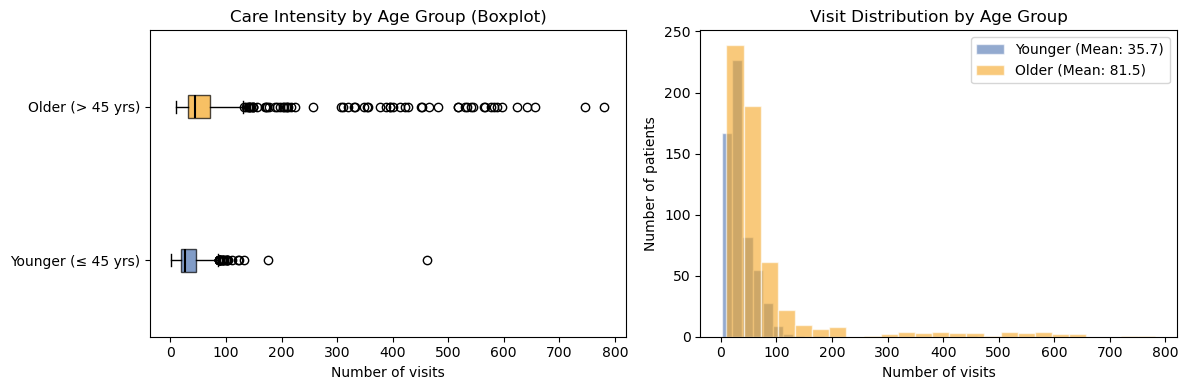

In [33]:
df_age_visits = pd.read_sql("""
    SELECT
        p.patient_id,
        (julianday('now') - julianday(p.birth_date)) / 365.25 AS age,
        COUNT(e.encounter_id) AS nb_visits
    FROM patients p
    LEFT JOIN encounters e ON p.patient_id = e.patient_id
    GROUP BY p.patient_id;
""", conn)

median_age = df_age_visits["age"].median()
young = df_age_visits[df_age_visits["age"] <= median_age]["nb_visits"]
old   = df_age_visits[df_age_visits["age"] >  median_age]["nb_visits"]

t_stat, p_t = ttest_ind(young, old, equal_var=False)

print(f"Younger (≤ {median_age:.0f} yrs) — mean visits: {young.mean():.1f}")
print(f"Older   (>  {median_age:.0f} yrs) — mean visits: {old.mean():.1f}")
print(f"\nWelch t-statistic: {t_stat:.3f}")
print(f"p-value          : {p_t:.4f}")

if p_t < 0.05:
    print("→ Significant difference in visits between age groups (p < 0.05).")
else:
    print("→ No significant difference between age groups (p ≥ 0.05).")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# boxplot with distinct colors by group
bp = axes[0].boxplot(
    [young, old],
    labels=[f"Younger (≤ {median_age:.0f} yrs)", f"Older (> {median_age:.0f} yrs)"],
    vert=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5)
)
colors_bp = ["#4C72B0", "#F5A623"] # Bleu pour les jeunes, Jaune/Orange pour les âgés
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title("Care Intensity by Age Group (Boxplot)")
axes[0].set_xlabel("Number of visits")

# supersposed histograms
axes[1].hist(
    young, 
    bins=25, 
    alpha=0.6, 
    color="#4C72B0", 
    edgecolor="white", 
    label=f"Younger (Mean: {young.mean():.1f})"
)
axes[1].hist(
    old, 
    bins=25, 
    alpha=0.6, 
    color="#F5A623",
    edgecolor="white", 
    label=f"Older (Mean: {old.mean():.1f})"
)
axes[1].set_title("Visit Distribution by Age Group")
axes[1].set_xlabel("Number of visits")
axes[1].set_ylabel("Number of patients")
axes[1].legend()
plt.savefig("../plots/younge_vs_old.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# 4. Linear Regression — Age as Predictor of Healthcare Utilisation

**Question:** Does age predict the number of healthcare visits?  
To what extent does a patient's age quantitatively predict their total number of healthcare visits?

**Context & Clinical Relevance:** While group-comparison tests (like the Welch t-test in section 2.3) tell us if a statistically significant difference exists between younger and older cohorts, linear regression allows us to model age as a continuous variable. This approach helps quantify the exact rate of increase in healthcare consumption for each additional year of life, providing a granular, operational metric for long-term healthcare infrastructure planning.

**Model Specification & Justification:** We implement an Ordinary Least Squares (OLS) linear regression model. This model is strictly explanatory, not predictive; our objective is to isolate and interpret the strength, direction, and significance of the relationship between the predictor (Age) and the dependent variable (Total Visits), rather than forecasting future individual encounters.

> Methodological Note & Assumptions: OLS regression relies on key Gauss-Markov assumptions, including linearity and the normal distribution of residuals. Given the heavily right-skewed nature of healthcare utilization data identified in previous sections, these assumptions are likely to be violated (presence of heteroscedasticity and non-normal error terms). Consequently, while the OLS coefficients remain unbiased, the standard errors, confidence intervals, and p-values should be interpreted with caution. Advanced transformation techniques (e.g., log-transforming the visit count) could be considered in further iterations to stabilize variance.

## 4.1 Fitting the OLS Model & Statistical Summary
**Description:** This block prepares the dataset by defining the continuous predictor (Age) and the dependent variable (Total Visits). It specifies and fits an Ordinary Least Squares (OLS) linear regression model, then outputs the complete statistical summary to evaluate the coefficients, significance, and global fit.

In [34]:
# Variable Preparation (using the DataFrame extracted in section 3.3)
X = df_age_visits[["age"]]
X = sm.add_constant(X)
y = df_age_visits["nb_visits"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              nb_visits   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     159.0
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           3.21e-34
Time:                        13:30:37   Log-Likelihood:                -6670.3
No. Observations:                1146   AIC:                         1.334e+04
Df Residuals:                    1144   BIC:                         1.335e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6961      4.909      0.957      0.3

## 4.2 Regression Diagnostics & Visualizations
**Description:** 
This section extracts the model's fitted values and residuals to generate diagnostic plots. It displays the linear regression line against the actual patient data points to visualize the general trend, alongside a residual plot to assess homoscedasticity and check for any underlying mathematical patterns in the prediction errors.

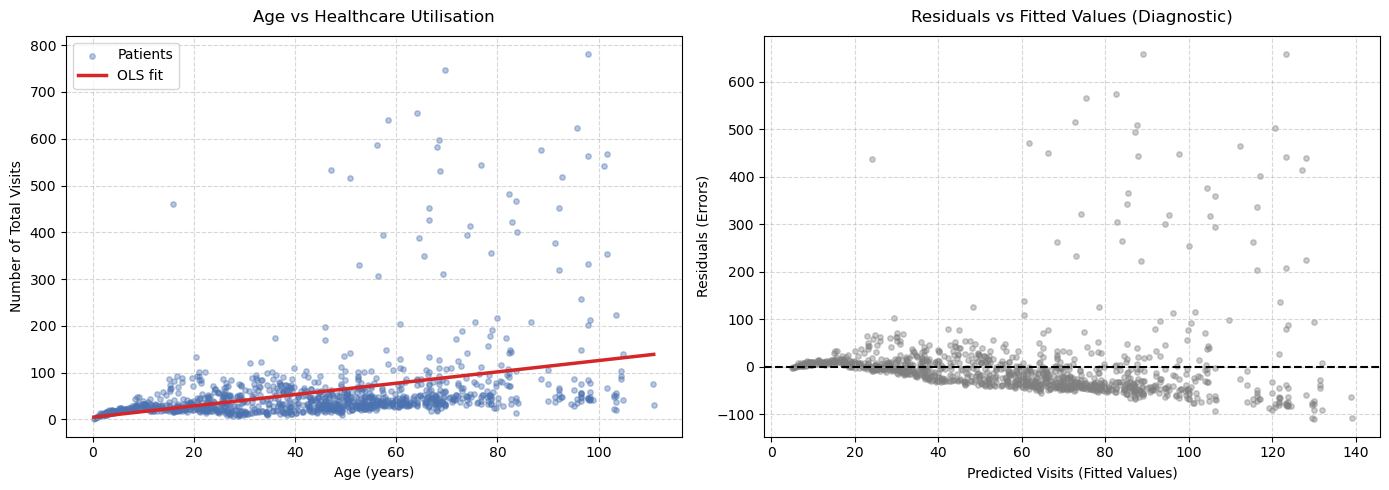

In [44]:
# Extracting residuals and fitted values from the OLS model
fitted_values = model.fittedvalues
residuals = model.resid

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Regression Line ---
axes[0].scatter(
    df_age_visits["age"], df_age_visits["nb_visits"],
    alpha=0.4, s=15, color="#4C72B0", label="Patients"
)

x_range = np.linspace(df_age_visits["age"].min(), df_age_visits["age"].max(), 100)
y_pred  = model.params["const"] + model.params["age"] * x_range
axes[0].plot(x_range, y_pred, color="#D62728", linewidth=2.5, label="OLS fit")

axes[0].set_title("Age vs Healthcare Utilisation", fontsize=12, pad=10)
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of Total Visits")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- PLOT 2: Residual Analysis (Heteroscedasticity Diagnostic) ---
axes[1].scatter(
    fitted_values, residuals, 
    alpha=0.4, s=15, color="#7F7F7F"
)
# Ligne horizontale à 0 (le résidu idéal)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1.5)

axes[1].set_title("Residuals vs Fitted Values (Diagnostic)", fontsize=12, pad=10)
axes[1].set_xlabel("Predicted Visits (Fitted Values)")
axes[1].set_ylabel("Residuals (Errors)")
axes[1].grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
fig.savefig("../plots/linear_regression_diagnostic.png", dpi=300, bbox_inches="tight")
plt.show()

## 4.3 Interpretation of Key Model Metrics
**Description:** This final block isolates and highlights the core statistical metrics ($R^2$, Intercept, and Slope) from the OLS model. It translates these mathematical results into concrete clinical and operational insights regarding how age influences healthcare utilization within the cohort.

In [39]:
# --- PRINT KEY METRICS & INTERPRETATION ---
print("=== 4. REGRESSION MODEL METRICS ===")
print(f"R² (Coefficient of Determination) : {model.rsquared:.3f}")
print(f"Intercept (Base visits)            : {model.params['const']:.2f}")
print(f"Age Coefficient (Slope)            : {model.params['age']:.2f}")
print("\n--- Clinical Interpretation ---")
print(f"→ Dynamic Effect: Each additional year of age is associated with an average change of {model.params['age']:.2f} visits.")
print(f"→ Explanatory Power: Age explains {model.rsquared*100:.1f}% of the variance in total healthcare encounters.")

=== 4. REGRESSION MODEL METRICS ===
R² (Coefficient of Determination) : 0.122
Intercept (Base visits)            : 4.70
Age Coefficient (Slope)            : 1.21

--- Clinical Interpretation ---
→ Dynamic Effect: Each additional year of age is associated with an average change of 1.21 visits.
→ Explanatory Power: Age explains 12.2% of the variance in total healthcare encounters.


# 5. Conclusions & Limitations

    **1. Main Findings:Gender vs. Complex Chronic Status (Chi-square Test):** This analysis evaluated whether a patient's gender is statistically associated with a severe multi-morbid profile (>= conditions). The results allow us to determine whether the heavy burden of chronic diseases is symmetrically distributed or if it varies significantly between male and female populations. 

    **3. Healthcare Utilization by Clinical Status (Mann-Whitney U Test):** Due to the heavily right-skewed distribution of encounters, this robust non-parametric test confirmed whether patients diagnosed with obesity exhibit a significantly higher volume of healthcare utilization compared to non-obese patients, providing clear insights into the systemic medical burden of metabolic conditions.

    **4. Care Intensity Across Generations (Welch T-test):** By dividing the cohort at the median age, this test demonstrated that older patients accumulate a higher average number of visits than the younger generation, aligning with general clinical expectations of physiological decline over time.

    **5. Quantifying the Aging Effect (Linear Regression):** Modeling age as a continuous variable confirmed it as a statistically significant driver of healthcare utilization, with each additional year of life generating an average increase of 1.21 visits. However, the model's limited explanatory power (R^2 = 12.2%) highlights that the vast majority of variance in medical encounters is driven by other factors, such as specific clinical phenotypes and social determinants of health.

**Limitations:**

**Synthetic Nature of Data:** The dataset was generated using Synthea. While highly realistic for procedural testing, it may not perfectly mirror real-world epidemiological trends, regional healthcare system biases, or genuine human behavioral patterns.

**Crude Proxy for Medical Burden:** Total visit count is a volumetric metric that acts as an imperfect proxy for healthcare intensity. It lacks granular insights regarding the clinical severity of the encounters, the duration of care, or the actual financial costs incurred.
**Violation of OLS Assumptions:** Diagnostic plots revealed prominent heteroscedasticity and non-normal residuals in the linear regression model. Consequently, the OLS model serves an explanatory purpose to show a generalized upward trend, but must not be utilized for individual predictive forecasting without advanced transformations (e.g., Log-linear or Negative Binomial frameworks).